In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


actions :
- 0: center
- 1: up
- 2: right
- 3: down
- 4: left

In [10]:
from luxai_s3.wrappers import LuxAIS3GymEnv 
import numpy as np
from base import BaseAgent, direction_to

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [11]:
from matplotlib.colors import ListedColormap
    
OUT_VISION = "#27213C"
EMPTY_C = "#F1E0C5"
NEBULA_C = "#477998"
ASTEROID_C = "#5B3000"

CMAP_TILES = ListedColormap([OUT_VISION, EMPTY_C, NEBULA_C, ASTEROID_C])  

RED = '#4CAF50'
GREEN = '#F44336'

def show_grid(grid):
    plt.figure(figsize=(7, 6))
    sns.heatmap(grid, cbar=True, linewidths=0.5, linecolor='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title("Grid")
    plt.show()

def show_tiles(tiles):
    plt.figure(figsize=(6, 6))
    sns.heatmap(tiles, cmap=CMAP_TILES, cbar=True, linewidths=0.5, linecolor='gray', vmin=-1, vmax=2)
    plt.xticks([])
    plt.yticks([])
    plt.title("Tiles", fontsize=14)
    plt.show()

In [12]:
class Agent():
    def __init__(self, player: str, env_cfg) -> None:
        self.player = player
        self.opp_player = "player_1" if self.player == "player_0" else "player_0"
        self.team_id = 0 if self.player == "player_0" else 1
        self.opp_team_id = 1 if self.team_id == 0 else 0
        np.random.seed(0)
        self.env_cfg = env_cfg
        
        self.relic_node_positions = []
        self.discovered_relic_nodes_ids = set()
        self.unit_explore_locations = dict()

        self.map_tiles = None

    def act(self, step: int, obs, remainingOverageTime: int = 60):
        """implement this function to decide what actions to send to each available unit. 
        
        step is the current timestep number of the game starting from 0 going up to max_steps_in_match * match_count_per_episode - 1.
        """
        unit_mask = np.array(obs["units_mask"][self.team_id]) # shape (max_units, )
        unit_positions = np.array(obs["units"]["position"][self.team_id]) # shape (max_units, 2)
        unit_energys = np.array(obs["units"]["energy"][self.team_id]) # shape (max_units, 1)
        self.map_tiles = np.array(obs["map_features"]["tile_type"])
        observed_relic_node_positions = np.array(obs["relic_nodes"]) # shape (max_relic_nodes, 2)
        observed_relic_nodes_mask = np.array(obs["relic_nodes_mask"]) # shape (max_relic_nodes, )
        team_points = np.array(obs["team_points"]) # points of each team, team_points[self.team_id] is the points of the your team
        
        # ids of units you can control at this timestep
        available_unit_ids = np.where(unit_mask)[0]
        # visible relic nodes
        visible_relic_node_ids = set(np.where(observed_relic_nodes_mask)[0])
        
        actions = np.zeros((self.env_cfg["max_units"], 3), dtype=int)


        # basic strategy here is simply to have some units randomly explore and some units collecting as much energy as possible
        # and once a relic node is found, we send all units to move randomly around the first relic node to gain points
        # and information about where relic nodes are found are saved for the next match
        
        # save any new relic nodes that we discover for the rest of the game.
        for id in visible_relic_node_ids:
            if id not in self.discovered_relic_nodes_ids:
                self.discovered_relic_nodes_ids.add(id)
                self.relic_node_positions.append(observed_relic_node_positions[id])
            

        # unit ids range from 0 to max_units - 1
        for unit_id in available_unit_ids:
            unit_pos = unit_positions[unit_id]
            unit_energy = unit_energys[unit_id]
            if len(self.relic_node_positions) > 0:
                nearest_relic_node_position = self.relic_node_positions[0]
                manhattan_distance = abs(unit_pos[0] - nearest_relic_node_position[0]) + abs(unit_pos[1] - nearest_relic_node_position[1])
                
                # if close to the relic node we want to hover around it and hope to gain points
                if manhattan_distance <= 4:
                    random_direction = np.random.randint(0, 5)
                    actions[unit_id] = [random_direction, 0, 0]
                else:
                    # otherwise we want to move towards the relic node
                    actions[unit_id] = [direction_to(unit_pos, nearest_relic_node_position), 0, 0]
            else:
                # randomly explore by picking a random location on the map and moving there for about 20 steps
                if step % 20 == 0 or unit_id not in self.unit_explore_locations:
                    rand_loc = (np.random.randint(0, self.env_cfg["map_width"]), np.random.randint(0, self.env_cfg["map_height"]))
                    self.unit_explore_locations[unit_id] = rand_loc
                actions[unit_id] = [direction_to(unit_pos, self.unit_explore_locations[unit_id]), 0, 0]
        return actions

    def get_map_tiles(self):
        return self.map_tiles

In [13]:
# Set environment
env = LuxAIS3GymEnv(numpy_output=True)
obs, info = env.reset()
env_cfg = info["params"]

# Initialise agents
player_0 = Agent("player_0", env_cfg)
player_1 = BaseAgent("player_1", env_cfg)

In [14]:
# Initialise match
obs, info = env.reset()
env_cfg = info["params"]
observations = []

# Store all observations of a match
for i in range(env_cfg["max_steps_in_match"]):
        # Take action 
    actions = {}
    for agent in [player_0, player_1]:
        actions[agent.player] = agent.act(step=i, obs=obs[agent.player])

    obs, rewards ,terminated, truncated, info = env.step(actions)
    observations.append(obs)

len(observations)

100

In [15]:
actions

{'player_0': array([[2, 0, 0],
        [2, 0, 0],
        [3, 0, 0],
        [2, 0, 0],
        [4, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        [4, 0, 0],
        [2, 0, 0],
        [0, 0, 0],
        [3, 0, 0],
        [3, 0, 0],
        [3, 0, 0],
        [3, 0, 0],
        [2, 0, 0]]),
 'player_1': array([[4, 0, 0],
        [1, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        [1, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        [1, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        [1, 0, 0],
        [4, 0, 0],
        [4, 0, 0],
        [4, 0, 0]])}

In [16]:
env_cfg

{'max_units': 16,
 'match_count_per_episode': 5,
 'max_steps_in_match': 100,
 'map_height': 24,
 'map_width': 24,
 'num_teams': 2,
 'unit_move_cost': 5,
 'unit_sap_cost': 40,
 'unit_sap_range': 3,
 'unit_sensor_range': 1}

In [17]:
i = 0
player = "player_0"
id_p = int(player[-1])

In [18]:
EMPTY_TILE = 0
NEBULA_TILE = 1
ASTEROID_TILE = 2

# Observation Elements
unit_pos = observations[i][f"player_{id_p}"]["units"]["position"][id_p]
unit_ene = observations[i][f"player_{id_p}"]["units"]["energy"][id_p]
vision = observations[i][f"player_{id_p}"]["sensor_mask"]
energies = observations[i][f"player_{id_p}"]["map_features"]["energy"]
tiles = observations[i][f"player_{id_p}"]["map_features"]["tile_type"]

print(i)
i+=1

unit_ene

0


array([100,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
        -1,  -1,  -1], dtype=int16)

In [19]:
vision

array([[ True,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False],
       [ True,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False],
       [False, False, False, False,

In [13]:
observations[0][f"player_{id_p}"]["map_features"].keys()#[id_p]

dict_keys(['energy', 'tile_type'])

In [14]:
observations[0][f"player_{id_p}"]["map_features"]["tile_type"]

array([[ 1,  2,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [ 1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [ 1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, 

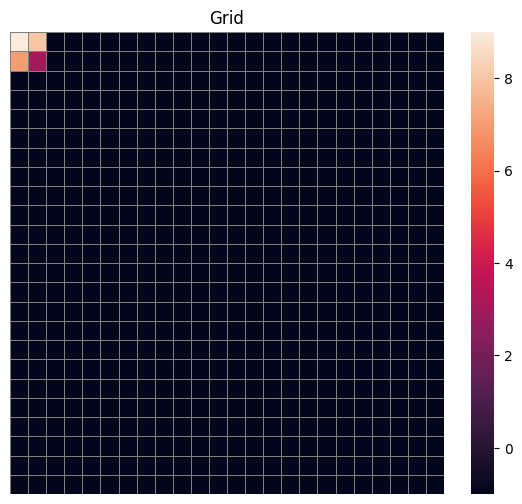

In [53]:
show_grid(energies)

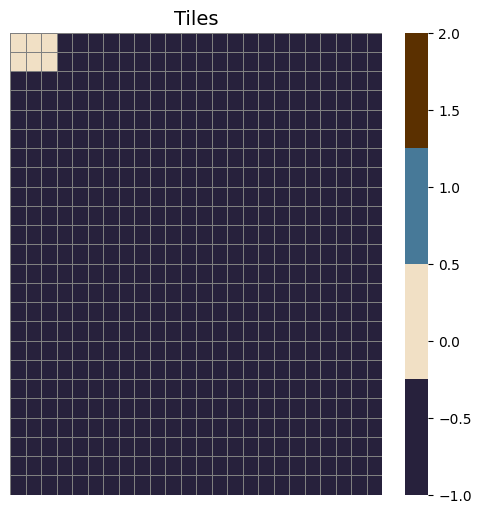

In [55]:
show_tiles(tiles)

In [34]:
unit_pos

array([[ 0,  0],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1],
       [-1, -1]], dtype=int16)

In [ ]:
# map knowledge

In [9]:
import json
from IPython.display import display, Javascript
from luxai_s3.wrappers import LuxAIS3GymEnv, RecordEpisode

def render_episode(episode: RecordEpisode) -> None:
    data = json.dumps(episode.serialize_episode_data(), separators=(",", ":"))
    display(Javascript(f"""
var iframe = document.createElement('iframe');
iframe.src = 'https://s3vis.lux-ai.org/#/kaggle';
iframe.width = '100%';
iframe.scrolling = 'no';

iframe.addEventListener('load', event => {{
    event.target.contentWindow.postMessage({data}, 'https://s3vis.lux-ai.org');
}});

new ResizeObserver(entries => {{
    for (const entry of entries) {{
        entry.target.height = `${{Math.round(320 + 0.3 * entry.contentRect.width)}}px`;
    }}
}}).observe(iframe);

element.append(iframe);
    """))

def evaluate_agents(agent_1_cls, agent_2_cls, seed=42, games_to_play=3, replay_save_dir="replays"):
    env = RecordEpisode(
        LuxAIS3GymEnv(numpy_output=True), save_on_close=True, save_on_reset=True, save_dir=replay_save_dir
    )

    obs, info = env.reset(seed=seed)
    for i in range(games_to_play):
        obs, info = env.reset()
        env_cfg = info["params"] # only contains observable game parameters
        player_0 = agent_1_cls("player_0", env_cfg)
        player_1 = agent_2_cls("player_1", env_cfg)
    
        # main game loop
        game_done = False
        step = 0
        print(f"Running game {i}")

        while not game_done:
            actions = dict()

            for agent in [player_0, player_1]:
                actions[agent.player] = agent.act(step=step, obs=obs[agent.player])

            obs, reward, terminated, truncated, info = env.step(actions)
            # info["state"] is the environment state object, you can inspect/play around with it to e.g. print
            # unobservable game data that agents can't see
            dones = {k: terminated[k] | truncated[k] for k in terminated}

            if dones["player_0"] or dones["player_1"]:
                game_done = True

            step += 1
        render_episode(env)
        
    env.close() # free up resources and save final replay

In [ ]:
evaluate_agents(Agent, Agent)